# 02 - Entrenamiento y seleccion del mejor modelo

Notebook principal de semana 3 para entrenamiento, comparacion y seleccion del mejor detector sobre CarDD COCO. El flujo queda autocontenido: define experimentos, entrena nuevas corridas si hace falta, compara el historial acumulado, elige el mejor checkpoint por `mAP@50:95`, lo evalua en test y verifica el artefacto final `dev/modelo.pth`.


## 1. Imports y configuración

In [1]:
# Importa dependencias, rutas del proyecto y helpers reutilizables de entrenamiento.
from pathlib import Path
import json
import random
import shutil
import sys

from IPython.display import display
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import torch

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from prod.detection_dataset import (
    CarDamageDetectionDataset,
    ComposeDetection,
    RandomHorizontalFlipDetection,
    RandomObjectCropDetection,
    ToTensorDetection,
    build_oversampling_sampler,
    resolve_target_class_ids,
    collate_fn,
)
from prod.detection_metrics import collect_detection_report
from prod.detection_models import (
    build_optimizer,
    create_model_from_config,
    describe_parameter_counts,
)
from prod.detection_training import load_checkpoint, run_detection_experiment
from utils import (
    append_jsonl_record,
    archive_canonical_detection_test_result,
    build_detection_test_results_comparison_df,
    detection_test_result_paths,
    export_detection_test_report_html,
    export_results_comparison_html,
    is_detection_test_report_complete,
    load_experiment_runs,
    make_experiment_run_record,
    resolve_portable_path,
    save_detection_test_result_artifacts,
    to_portable_path,
)


In [2]:
# Fija semillas y define todas las rutas de artefactos que usa el notebook.
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "dev" / "experiments"
RUNS_MANIFEST_PATH = PROJECT_ROOT / "dev" / "runs_manifest.jsonl"
RESULTS_HTML_PATH = PROJECT_ROOT / "dev" / "results_comparison.html"
BEST_TEST_RESULT_PATH = PROJECT_ROOT / "dev" / "best_test_result.json"
BEST_TEST_REPORT_HTML_PATH = PROJECT_ROOT / "dev" / "best_test_result_report.html"
TEST_RESULTS_DIR = PROJECT_ROOT / "dev" / "test_results"
UPDATE_CANONICAL_BEST_TEST_RESULT = False
FINAL_MODEL_PATH = PROJECT_ROOT / "dev" / "modelo.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("DATA_DIR:", DATA_DIR)
print("RUNS_MANIFEST_PATH:", RUNS_MANIFEST_PATH)
print("RESULTS_HTML_PATH:", RESULTS_HTML_PATH)
print("BEST_TEST_RESULT_PATH:", BEST_TEST_RESULT_PATH)
print("BEST_TEST_REPORT_HTML_PATH:", BEST_TEST_REPORT_HTML_PATH)
print("TEST_RESULTS_DIR:", TEST_RESULTS_DIR)
print("UPDATE_CANONICAL_BEST_TEST_RESULT:", UPDATE_CANONICAL_BEST_TEST_RESULT)
print("FINAL_MODEL_PATH:", FINAL_MODEL_PATH)


Device: cpu
DATA_DIR: /home/joaquin/code/proyecto_final_redes/data
RUNS_MANIFEST_PATH: /home/joaquin/code/proyecto_final_redes/dev/runs_manifest.jsonl
RESULTS_HTML_PATH: /home/joaquin/code/proyecto_final_redes/dev/results_comparison.html
BEST_TEST_RESULT_PATH: /home/joaquin/code/proyecto_final_redes/dev/best_test_result.json
FINAL_MODEL_PATH: /home/joaquin/code/proyecto_final_redes/dev/modelo.pth


## 2. Verificación del dataset local

Este notebook requiere las imágenes reales del dataset en `train2017`, `val2017` y `test2017`.

In [3]:
# Verifica que existan las carpetas mínimas del dataset antes de entrenar.
required_dirs = [
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "train2017",
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "val2017",
    DATA_DIR / "CarDD_release" / "CarDD_COCO" / "test2017",
]
missing_dirs = [path for path in required_dirs if not path.exists()]
if missing_dirs:
    raise FileNotFoundError(
        "Faltan las carpetas de imagenes necesarias para entrenar:\n" + "\n".join(str(path) for path in missing_dirs)
    )

print("Dataset listo para entrenamiento.")


Dataset listo para entrenamiento.


## 3. Datasets y DataLoaders

In [4]:
# Construye datasets y dataloaders base con augmentations simples de entrenamiento.
BATCH_SIZE = 5
NUM_WORKERS = 0
BASE_MODEL_NAME = "fasterrcnn"

train_transform = ComposeDetection([
    ToTensorDetection(),
    RandomHorizontalFlipDetection(p=0.5),
])

eval_transform = ComposeDetection([
    ToTensorDetection(),
])

train_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="train",
    transform=train_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

val_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="val",
    transform=eval_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

test_dataset = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="test",
    transform=eval_transform,
    model_name=BASE_MODEL_NAME,
    resize=False,
    image_size=None,
)

NUM_CLASSES = len(train_dataset.class_to_idx)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

print("Clases:", NUM_CLASSES)
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


Clases: 7
Train samples: 2816
Val samples: 810
Test samples: 374


## 4. Experimentos disponibles

Se comparan detectores preentrenados de `torchvision` porque el problema es de deteccion con bounding boxes, no de clasificacion pura. La arquitectura final de cada modelo se adapta reemplazando la cabeza de clasificacion para `NUM_CLASSES` clases y variando `trainable_backbone_layers` como estrategia de fine-tuning.


In [5]:
# Declara el catálogo de experimentos que se pueden comparar en esta etapa.
EXPERIMENTS = [
    {
        "name": "fcos_partial_backbone_fixed_size",
        "model_name": "fcos",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "retinanet_partial_backbone_fixed_size",
        "model_name": "retinanet",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
{
        "name": "fcos_partial_backbone_fixed_size",
        "model_name": "fcos",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "adamw",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    },
    {
        "name": "retinanet_partial_backbone_fixed_size",
        "model_name": "retinanet",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "adamw",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 5,
        "resize": True,
        "image_size": (640, 640),
    }, 
    {
        "name": "fasterrcnn_mobilenet_v3_large_partial_backbone",
        "model_name": "fasterrcnn_mobilenet_v3_large_fpn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 10,
        "resize": False,
        "image_size": None,
    },

    {
        "name": "fasterrcnn_mobilenet_v3_large_dent_scratch_oversample_crop",
        "model_name": "fasterrcnn_mobilenet_v3_large_fpn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 10,
        "resize": False,
        "image_size": None,
        "target_classes": ["dent", "scratch"],
        "oversample_target_factor": 2.5,
        "use_object_crop": True,
        "object_crop_probability": 0.5,
    },
    {
        "name": "fasterrcnn_mobilenet_v3_large_320_partial_backbone",
        "model_name": "fasterrcnn_mobilenet_v3_large_320_fpn",
        "num_classes": NUM_CLASSES,
        "trainable_backbone_layers": 2,
        "optimizer_name": "sgd",
        "lr": 0.002,
        "momentum": 0.9,
        "weight_decay": 0.0005,
        "num_epochs": 10,
        "resize": False,
        "image_size": None,
    },
]

pd.DataFrame(EXPERIMENTS)[[
    "name",
    "model_name",
    "trainable_backbone_layers",
    "lr",
    "num_epochs",
    "resize",
    "image_size",
    "target_classes",
    "oversample_target_factor",
    "use_object_crop",
    "object_crop_probability",
]]


,name,model_name,trainable_backbone_layers,lr,num_epochs,resize,image_size
0,fcos_partial_backbone_fixed_size,fcos,2,0.002,5,True,"(640, 640)"
1,retinanet_partial_backbone_fixed_size,retinanet,2,0.002,5,True,"(640, 640)"
2,fcos_partial_backbone_fixed_size,fcos,2,0.002,5,True,"(640, 640)"
3,retinanet_partial_backbone_fixed_size,retinanet,2,0.002,5,True,"(640, 640)"
4,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,0.002,10,False,None
5,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,0.002,10,False,None


In [6]:
# Permite seleccionar una sublista de experimentos para ejecutar en la corrida actual.
SELECTED_EXPERIMENT_INDICES = []
SELECTED_EXPERIMENTS = [EXPERIMENTS[i] for i in SELECTED_EXPERIMENT_INDICES]

selected_columns = [
    "name",
    "model_name",
    "trainable_backbone_layers",
    "lr",
    "num_epochs",
    "resize",
    "image_size",
    "target_classes",
    "oversample_target_factor",
    "use_object_crop",
    "object_crop_probability",
]

if SELECTED_EXPERIMENTS:
    display(pd.DataFrame(SELECTED_EXPERIMENTS)[selected_columns])
else:
    print("No hay experimentos seleccionados para entrenar en esta corrida. Se usaran las corridas ya guardadas para el resto del notebook.")
    display(pd.DataFrame(columns=selected_columns))


No hay experimentos seleccionados para entrenar en esta corrida. Se usaran las corridas ya guardadas para el resto del notebook.


,name,model_name,trainable_backbone_layers,lr,num_epochs,resize,image_size


## 5. Helpers de entrenamiento

In [7]:
# Define helpers de armado de dataloaders, plotting y tablas de análisis del experimento.
def build_train_transform_for_experiment(experiment, dataset):
    transforms = []
    if experiment.get("use_object_crop", False):
        target_classes = experiment.get("target_classes", ["dent", "scratch"])
        target_class_ids = resolve_target_class_ids(dataset, target_classes)
        transforms.append(
            RandomObjectCropDetection(
                p=experiment.get("object_crop_probability", 0.5),
                target_class_ids=target_class_ids,
            )
        )

    transforms.extend([
        ToTensorDetection(),
        RandomHorizontalFlipDetection(p=0.5),
    ])
    return ComposeDetection(transforms)


def build_train_sampler_for_experiment(experiment, dataset):
    target_factor = experiment.get("oversample_target_factor")
    if target_factor is None or float(target_factor) <= 1.0:
        return None

    return build_oversampling_sampler(
        dataset=dataset,
        target_classes=experiment.get("target_classes", ["dent", "scratch"]),
        target_factor=float(target_factor),
        num_samples=len(dataset),
        replacement=True,
    )


def build_dataloaders_for_experiment(experiment):
    train_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="train",
        transform=None,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )
    train_dataset.transform = build_train_transform_for_experiment(experiment, train_dataset)

    val_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="val",
        transform=eval_transform,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )
    test_dataset = CarDamageDetectionDataset(
        data_dir=DATA_DIR,
        split="test",
        transform=eval_transform,
        model_name=experiment["model_name"],
        resize=experiment["resize"],
        image_size=experiment["image_size"],
    )

    train_sampler = build_train_sampler_for_experiment(experiment, train_dataset)
    train_loader = torch.utils.data.DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=train_sampler is None,
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )
    test_loader = torch.utils.data.DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=collate_fn,
    )

    return train_loader, val_loader, test_loader

def plot_history(history, title):
    history_df = pd.DataFrame(history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoca")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["map"], label="mAP@50:95")
    axes[1].plot(history_df["epoch"], history_df["map_50"], label="mAP@50")
    axes[1].set_title(f"{title} - mAP")
    axes[1].set_xlabel("Epoca")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def build_experiment_catalog_df(experiments):
    rows = []
    for experiment in experiments:
        rows.append(
            {
                "name": experiment["name"],
                "model_name": experiment["model_name"],
                "trainable_backbone_layers": experiment["trainable_backbone_layers"],
                "optimizer": experiment["optimizer_name"],
                "lr": experiment["lr"],
                "num_epochs": experiment["num_epochs"],
                "resize": experiment["resize"],
                "image_size": experiment["image_size"],
            }
        )
    return pd.DataFrame(rows)


def build_results_display_df(results_df):
    rows = []
    for _, row in results_df.iterrows():
        config = row.get("config") or {}
        duration_seconds = row.get("training_duration_seconds")
        rows.append(
            {
                "experimento": row.get("name"),
                "modelo": config.get("model_name"),
                "backbone_entrenable": row.get("trainable_backbone_layers", config.get("trainable_backbone_layers")),
                "optimizer": row.get("optimizer_name", config.get("optimizer_name")),
                "epocas": row.get("num_epochs", config.get("num_epochs")),
                "best_epoch": row.get("best_epoch"),
                "best_map": row.get("best_map"),
                "best_map_50": row.get("best_map_50"),
                "best_val_loss": row.get("best_val_loss"),
                "duracion_min": round(float(duration_seconds) / 60.0, 1) if pd.notna(duration_seconds) else None,
                "checkpoint_path": row.get("checkpoint_path"),
            }
        )

    display_df = pd.DataFrame(rows)
    metric_columns = ["best_map", "best_map_50", "best_val_loss"]
    for column in metric_columns:
        if column in display_df.columns:
            display_df[column] = display_df[column].map(lambda value: round(float(value), 4) if pd.notna(value) else value)
    return display_df


def build_class_metrics_table(test_metrics, idx_to_class):
    classes = test_metrics.get("classes") or []
    map_per_class = test_metrics.get("map_per_class") or []
    mar_per_class = test_metrics.get("mar_100_per_class") or []
    if not classes or not map_per_class:
        return pd.DataFrame()

    rows = []
    for index, class_id in enumerate(classes):
        class_id = int(class_id)
        rows.append(
            {
                "class_id": class_id,
                "class_name": idx_to_class.get(class_id, f"class_{class_id}"),
                "map_per_class": round(float(map_per_class[index]), 4),
                "mar_100_per_class": round(float(mar_per_class[index]), 4) if index < len(mar_per_class) else None,
            }
        )
    return pd.DataFrame(rows).sort_values(by="map_per_class", ascending=False).reset_index(drop=True)


def summarize_training_dynamics(history):
    history_df = pd.DataFrame(history)
    if history_df.empty:
        return "No hay historial disponible para interpretar la dinamica de entrenamiento."

    best_idx = history_df["map"].idxmax()
    best_epoch = int(history_df.loc[best_idx, "epoch"])
    best_map = float(history_df.loc[best_idx, "map"])
    final_epoch = int(history_df.iloc[-1]["epoch"])
    final_map = float(history_df.iloc[-1]["map"])
    final_train_loss = float(history_df.iloc[-1]["train_loss"])
    final_val_loss = float(history_df.iloc[-1]["val_loss"])
    loss_gap = final_val_loss - final_train_loss

    if best_epoch < final_epoch and final_map < best_map:
        fit_note = "Hay senales leves de sobreajuste despues del pico de validacion, porque el mejor mAP aparece antes del final y luego cae ligeramente."
    elif loss_gap > 0.15:
        fit_note = "La brecha entre train y validacion sugiere sobreajuste moderado, aunque la curva sigue estable."
    else:
        fit_note = "No se observan senales fuertes de sobreajuste; train y validacion evolucionan de forma relativamente acompasada."

    return (
        f"Mejor epoca: {best_epoch} con mAP@50:95={best_map:.4f}. "
        f"Ultima epoca: {final_epoch} con mAP@50:95={final_map:.4f}, "
        f"train_loss={final_train_loss:.4f} y val_loss={final_val_loss:.4f}. "
        f"{fit_note}"
    )


def draw_boxes(ax, boxes, labels, idx_to_class, color, prefix, scores=None):
    for box_index, box in enumerate(boxes):
        x1, y1, x2, y2 = [float(value) for value in box]
        width = max(x2 - x1, 1.0)
        height = max(y2 - y1, 1.0)
        rectangle = patches.Rectangle(
            (x1, y1),
            width,
            height,
            linewidth=2,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rectangle)

        class_id = int(labels[box_index]) if len(labels) > box_index else -1
        class_name = idx_to_class.get(class_id, str(class_id))
        label_text = f"{prefix}: {class_name}"
        if scores is not None and len(scores) > box_index:
            label_text += f" ({float(scores[box_index]):.2f})"
        ax.text(
            x1,
            max(y1 - 4, 2),
            label_text,
            fontsize=8,
            color="white",
            bbox={"facecolor": color, "alpha": 0.75, "pad": 2},
        )


def collect_error_analysis_examples(model, dataset, device, score_threshold=0.4, max_examples=6):
    # Pone el modelo en evaluacion para generar predicciones deterministicas.
    model.eval()
    examples = []

    # Desactiva gradientes porque solo queremos inferencia sobre muestras de test.
    with torch.no_grad():
        for sample_index in range(len(dataset)):
            # Recupera una muestra ya transformada y su target real.
            image, target = dataset[sample_index]
            prediction = model([image.to(device)])[0]

            # Filtra predicciones de baja confianza para quedarnos con las mas relevantes.
            pred_scores = prediction["scores"].detach().cpu()
            keep_mask = pred_scores >= score_threshold
            pred_boxes = prediction["boxes"].detach().cpu()[keep_mask]
            pred_labels = prediction["labels"].detach().cpu()[keep_mask]
            pred_scores = pred_scores[keep_mask]

            # Lleva tambien el ground truth a CPU para poder compararlo facilmente.
            gt_boxes = target["boxes"].detach().cpu()
            gt_labels = target["labels"].detach().cpu()

            # Marca errores simples y faciles de interpretar visualmente:
            # menos cajas que las esperadas, mas cajas de las esperadas,
            # conjunto distinto de etiquetas o ausencia total de predicciones.
            missing_predictions = len(pred_boxes) < len(gt_boxes)
            extra_predictions = len(pred_boxes) > len(gt_boxes)
            label_mismatch = set(pred_labels.tolist()) != set(gt_labels.tolist())
            empty_predictions = len(pred_boxes) == 0
            is_error_case = missing_predictions or extra_predictions or label_mismatch or empty_predictions

            # Si la muestra cae en alguno de esos casos, la guarda para inspeccion posterior.
            if is_error_case:
                examples.append(
                    {
                        "sample_index": sample_index,
                        "image": image.detach().cpu(),
                        "target": target,
                        "pred_boxes": pred_boxes,
                        "pred_labels": pred_labels,
                        "pred_scores": pred_scores,
                        "comment": (
                            f"GT boxes={len(gt_boxes)}, pred boxes={len(pred_boxes)}, "
                            f"label_mismatch={label_mismatch}"
                        ),
                    }
                )

            # Corta cuando ya reunio suficientes ejemplos para la visualizacion.
            if len(examples) >= max_examples:
                break

    return examples


def plot_error_analysis_examples(examples, idx_to_class):
    if not examples:
        print("No se encontraron ejemplos problematicos con el umbral elegido.")
        return

    columns = 2
    rows = (len(examples) + columns - 1) // columns
    fig, axes = plt.subplots(rows, columns, figsize=(15, 5 * rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, example in zip(axes, examples):
        image = example["image"].permute(1, 2, 0).clamp(0, 1).numpy()
        ax.imshow(image)
        draw_boxes(ax, example["target"]["boxes"].detach().cpu(), example["target"]["labels"].detach().cpu(), idx_to_class, "lime", "GT")
        draw_boxes(ax, example["pred_boxes"], example["pred_labels"], idx_to_class, "crimson", "Pred", example["pred_scores"])
        ax.set_title(f"Muestra {example['sample_index']} | {example['comment']}")
        ax.axis("off")

    for ax in axes[len(examples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()



## 6. Ejecucion de la tanda seleccionada

Cada experimento terminado se agrega como una linea JSON en `dev/runs_manifest.jsonl`. Si repetis un experimento, queda guardado como otra corrida historica.

In [8]:
# Ejecuta los experimentos seleccionados, guarda checkpoints y registra cada corrida en el manifest.
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
experiment_summaries = []
experiment_runs = {}

if not SELECTED_EXPERIMENTS:
    print("Se omite el entrenamiento porque SELECTED_EXPERIMENTS esta vacio.")
else:
    for experiment in SELECTED_EXPERIMENTS:
        print(f"\n===== {experiment['name']} =====")

        train_loader_exp, val_loader_exp, test_loader_exp = build_dataloaders_for_experiment(experiment)
        model = create_model_from_config(experiment)
        optimizer = build_optimizer(
            model,
            optimizer_name=experiment["optimizer_name"],
            lr=experiment["lr"],
            momentum=experiment["momentum"],
            weight_decay=experiment["weight_decay"],
        )

        parameter_counts = describe_parameter_counts(model)
        print(parameter_counts)

        run_result = run_detection_experiment(
            model=model,
            train_loader=train_loader_exp,
            val_loader=val_loader_exp,
            optimizer=optimizer,
            device=DEVICE,
            num_epochs=experiment["num_epochs"],
            experiment_name=experiment["name"],
            config=experiment,
            output_dir=ARTIFACTS_DIR,
            class_metrics=True,
        )

        experiment_runs[experiment["name"]] = {
            "config": experiment,
            "run_result": run_result,
            "test_loader": test_loader_exp,
        }

        history_df = pd.DataFrame(run_result["history"])
        best_row = history_df.loc[history_df["map"].idxmax()].to_dict()
        run_record = make_experiment_run_record(experiment, run_result, best_row)
        if run_record["checkpoint_path"] is not None:
            archived_checkpoint_path = ARTIFACTS_DIR / f"{run_record['run_id']}_best.pth"
            source_checkpoint_path = resolve_portable_path(
                run_record["checkpoint_path"],
                base_dir=PROJECT_ROOT,
                fallback_dir=ARTIFACTS_DIR,
            )
            shutil.copy2(source_checkpoint_path, archived_checkpoint_path)
            run_record["checkpoint_path"] = to_portable_path(
                archived_checkpoint_path,
                base_dir=PROJECT_ROOT,
            )
        append_jsonl_record(RUNS_MANIFEST_PATH, run_record)
        experiment_summaries.append(run_record)
        print(f"Corrida guardada en manifest: {RUNS_MANIFEST_PATH}")

        plot_history(run_result["history"], experiment["name"])


Se omite el entrenamiento porque SELECTED_EXPERIMENTS esta vacio.


## 7. Comparacion acumulada de resultados

Esta tabla lee todas las corridas guardadas en `runs_manifest.jsonl`, incluyendo tandas anteriores. Resume el historial experimental y muestra como cambia el rendimiento entre configuraciones distintas.


In [9]:
# Carga todas las corridas históricas, genera la tabla comparativa y exporta HTML.
all_runs_df = load_experiment_runs(RUNS_MANIFEST_PATH)
if all_runs_df.empty:
    raise ValueError(f"No hay corridas guardadas en {RUNS_MANIFEST_PATH}")

results_df = all_runs_df.sort_values(by="best_map", ascending=False).reset_index(drop=True)
results_table_df = build_results_display_df(results_df)
results_html_path = export_results_comparison_html(
    results_df.drop(columns=["config", "history"], errors="ignore"),
    RESULTS_HTML_PATH,
)
print(f"Tabla acumulada exportada a HTML en: {results_html_path}")
display(results_table_df)


Tabla acumulada exportada a HTML en: /home/joaquin/code/proyecto_final_redes/dev/results_comparison.html


,experimento,modelo,backbone_entrenable,optimizer,epocas,best_epoch,best_map,best_map_50,best_val_loss,duracion_min,checkpoint_path
0,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,sgd,10,7,0.4411,0.6298,0.6465,32.3,dev/experiments/20260612_153757_fasterrcnn_mob...
1,fcos_partial_backbone_fixed_size,fcos,2,sgd,5,5,0.4386,0.5767,1.2516,33.9,dev/experiments/20260612_121844_fcos_partial_b...
2,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,sgd,5,5,0.4375,0.6243,0.6266,14.7,dev/experiments/20260612_144006_fasterrcnn_mob...
3,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,sgd,10,9,0.3953,0.5782,0.5711,20.3,dev/experiments/20260612_155817_fasterrcnn_mob...
4,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,sgd,5,5,0.3889,0.5715,0.5694,9.3,dev/experiments/20260612_150327_fasterrcnn_mob...
5,retinanet_partial_backbone_fixed_size,retinanet,2,sgd,5,5,0.3705,0.4747,0.6827,26.0,dev/experiments/20260612_124444_retinanet_part...
6,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,0,sgd,5,5,0.3308,0.5084,0.4682,9.3,dev/experiments/20260612_141634_fasterrcnn_mob...
7,fcos_partial_backbone_fixed_size,fcos,2,adamw,5,3,0.0105,0.0419,1.7830,34.0,dev/experiments/20260612_131843_fcos_partial_b...
8,retinanet_partial_backbone_fixed_size,retinanet,2,adamw,5,1,0.0000,0.0000,1.6734,26.0,dev/experiments/20260612_134443_retinanet_part...


## 8. Modelo preentrenado, arquitectura y estrategia de fine-tuning

El problema del proyecto es deteccion de daños con bounding boxes sobre CarDD COCO. Por eso se eligieron detectores preentrenados de `torchvision` en lugar de clasificadores puros como ResNet o ViT: necesitamos localizar y clasificar multiples daños dentro de la misma imagen.

Decisiones de arquitectura:
- Todos los modelos parten de pesos `DEFAULT` preentrenados.
- La adaptacion al problema local consiste en reemplazar la cabeza de clasificacion para `NUM_CLASSES` clases.
- El grado de fine-tuning se controla con `trainable_backbone_layers`.
- Se probaron detectores de una etapa (`FCOS`, `RetinaNet`) y de dos etapas (`Faster R-CNN` y variantes MobileNet V3) para comparar precision, estabilidad y costo computacional.


In [10]:
# Resume el catálogo experimental completo y el setup de hardware/augmentations usado.
experiment_catalog_df = build_experiment_catalog_df(EXPERIMENTS)
display(experiment_catalog_df)

hardware_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
training_setup_df = pd.DataFrame(
    [
        {
            "batch_size": BATCH_SIZE,
            "num_workers": NUM_WORKERS,
            "augmentations_train": "ToTensor + RandomHorizontalFlip(p=0.5)",
            "augmentations_eval": "ToTensor",
            "loss_strategy": "Loss compuesta nativa del detector torchvision",
            "scheduler": "No usado",
            "hardware": hardware_name,
            "device": str(DEVICE),
        }
    ]
)
display(training_setup_df)


,name,model_name,trainable_backbone_layers,optimizer,lr,num_epochs,resize,image_size
0,fcos_partial_backbone_fixed_size,fcos,2,sgd,0.002,5,True,"(640, 640)"
1,retinanet_partial_backbone_fixed_size,retinanet,2,sgd,0.002,5,True,"(640, 640)"
2,fcos_partial_backbone_fixed_size,fcos,2,adamw,0.002,5,True,"(640, 640)"
3,retinanet_partial_backbone_fixed_size,retinanet,2,adamw,0.002,5,True,"(640, 640)"
4,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,sgd,0.002,10,False,None
5,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,sgd,0.002,10,False,None


,batch_size,num_workers,augmentations_train,augmentations_eval,loss_strategy,scheduler,hardware,device
0,5,0,ToTensor + RandomHorizontalFlip(p=0.5),ToTensor,Loss compuesta nativa del detector torchvision,No usado,CPU,cpu


## 9. Lectura de la experimentacion

La comparacion acumulada de `runs_manifest.jsonl` permite resumir varios patrones observables en las corridas:

- Los detectores de una etapa (`FCOS`, `RetinaNet`) sirvieron como baseline, pero no fueron los mas competitivos en `mAP@50:95` dentro de las corridas guardadas.
- Las variantes de `Faster R-CNN` con backbone MobileNet V3 mejoraron el equilibrio entre precision y tiempo de entrenamiento.
- El fine-tuning parcial del backbone mostro un mejor compromiso que congelar casi todo el modelo o abrir demasiadas capas de golpe.
- En las corridas disponibles, `SGD` fue mas estable que `AdamW` para este problema y estos hiperparametros.


In [11]:
# Muestra una vista compacta de comparación entre las mejores corridas registradas.
comparison_columns = [
    "experimento",
    "modelo",
    "backbone_entrenable",
    "optimizer",
    "epocas",
    "best_map",
    "best_map_50",
    "duracion_min",
]
comparison_df = results_table_df[comparison_columns].copy()
display(comparison_df.head(10))


,experimento,modelo,backbone_entrenable,optimizer,epocas,best_map,best_map_50,duracion_min
0,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,sgd,10,0.4411,0.6298,32.3
1,fcos_partial_backbone_fixed_size,fcos,2,sgd,5,0.4386,0.5767,33.9
2,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,2,sgd,5,0.4375,0.6243,14.7
3,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,sgd,10,0.3953,0.5782,20.3
4,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,2,sgd,5,0.3889,0.5715,9.3
5,retinanet_partial_backbone_fixed_size,retinanet,2,sgd,5,0.3705,0.4747,26.0
6,fasterrcnn_mobilenet_v3_large_320_partial_back...,fasterrcnn_mobilenet_v3_large_320_fpn,0,sgd,5,0.3308,0.5084,9.3
7,fcos_partial_backbone_fixed_size,fcos,2,adamw,5,0.0105,0.0419,34.0
8,retinanet_partial_backbone_fixed_size,retinanet,2,adamw,5,0.0000,0.0000,26.0


## 10. Seleccion del mejor modelo por validacion

La seleccion final se hace sobre el mejor `best_map` de validacion, no sobre test. Reci?n despues se evalua en test para evitar usar el conjunto final durante la toma de decisiones.


In [12]:
# Recupera la mejor corrida global y resume su configuración, métricas y tamaño de modelo.
best_run = results_df.iloc[0].to_dict()
best_config = best_run["config"]
best_checkpoint_path = resolve_portable_path(
    best_run["checkpoint_path"],
    base_dir=PROJECT_ROOT,
    fallback_dir=ARTIFACTS_DIR,
)

best_run_summary_df = pd.DataFrame(
    [
        {
            "run_id": best_run["run_id"],
            "experimento": best_run["name"],
            "modelo": best_config["model_name"],
            "optimizer": best_run.get("optimizer_name", best_config.get("optimizer_name")),
            "trainable_backbone_layers": best_run.get("trainable_backbone_layers", best_config.get("trainable_backbone_layers")),
            "best_epoch": best_run["best_epoch"],
            "best_map": round(float(best_run["best_map"]), 4),
            "best_map_50": round(float(best_run["best_map_50"]), 4),
            "checkpoint_path": to_portable_path(best_checkpoint_path, base_dir=PROJECT_ROOT),
        }
    ]
)
display(best_run_summary_df)

best_model_for_summary = create_model_from_config(best_config)
parameter_counts = describe_parameter_counts(best_model_for_summary)
best_model_summary_df = pd.DataFrame(
    [
        {
            "modelo": best_config["model_name"],
            "pesos_preentrenados": "torchvision DEFAULT",
            "num_classes": best_config["num_classes"],
            "trainable_backbone_layers": best_config["trainable_backbone_layers"],
            "optimizer": best_config["optimizer_name"],
            "lr": best_config["lr"],
            "weight_decay": best_config["weight_decay"],
            "num_epochs": best_config["num_epochs"],
            "resize": best_config["resize"],
            "image_size": best_config["image_size"],
            "trainable_parameters": parameter_counts["trainable_parameters"],
            "frozen_parameters": parameter_counts["frozen_parameters"],
            "total_parameters": parameter_counts["total_parameters"],
        }
    ]
)
display(best_model_summary_df)


,run_id,experimento,modelo,optimizer,trainable_backbone_layers,best_epoch,best_map,best_map_50,checkpoint_path
0,20260612_153757_fasterrcnn_mobilenet_v3_large_...,fasterrcnn_mobilenet_v3_large_partial_backbone,fasterrcnn_mobilenet_v3_large_fpn,sgd,2,7,0.4411,0.6298,dev/experiments/20260612_153757_fasterrcnn_mob...


,modelo,pesos_preentrenados,num_classes,trainable_backbone_layers,optimizer,lr,weight_decay,num_epochs,resize,image_size,trainable_parameters,frozen_parameters,total_parameters
0,fasterrcnn_mobilenet_v3_large_fpn,torchvision DEFAULT,7,2,sgd,0.002,0.0005,10,False,None,18174518,781336,18955854


## 11. Curvas del modelo elegido e interpretacion

Las curvas de loss y mAP ayudan a ver si el modelo sigue aprendiendo, si se estabiliza o si empieza a sobreajustar. La lectura final debe apoyarse en el mejor checkpoint y no solo en la ultima epoca.


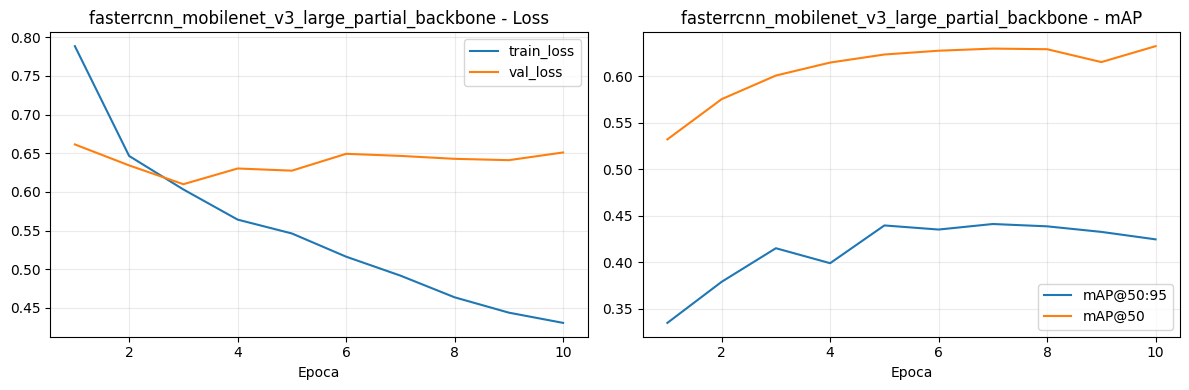

Mejor epoca: 7 con mAP@50:95=0.4411. Ultima epoca: 10 con mAP@50:95=0.4246, train_loss=0.4307 y val_loss=0.6510. Hay senales leves de sobreajuste despues del pico de validacion, porque el mejor mAP aparece antes del final y luego cae ligeramente.


In [13]:
# Grafica la historia de la mejor corrida y genera una lectura rápida de su dinámica.
best_history = best_run.get("history") or []
plot_history(best_history, best_run["name"])
print(summarize_training_dynamics(best_history))


## 12. Evaluacion final en test

Despues de elegir el mejor checkpoint por validacion, se reconstruye el dataloader de test con la misma configuracion de resize del experimento ganador y se calcula `mAP@50:95`, `mAP@50`, `mAP@75` y `mAR@100`.


In [14]:
# Evalua en test el mejor checkpoint y guarda resultados por corrida sin pisar el baseline canonico.
USE_CACHED_TEST_RESULT = True
TEST_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
archived_baseline_path = archive_canonical_detection_test_result(
    BEST_TEST_RESULT_PATH,
    TEST_RESULTS_DIR,
    overwrite=False,
)
if archived_baseline_path is not None:
    print(f"Baseline canonico archivado/disponible en: {archived_baseline_path}")

expected_checkpoint_path = to_portable_path(best_checkpoint_path, base_dir=PROJECT_ROOT)
per_run_result_paths = detection_test_result_paths(best_run["run_id"], TEST_RESULTS_DIR)
cached_test_result = None

# Reconstruye dataset y modelo porque las secciones siguientes siguen dependiendo de ellos.
eval_transform = ComposeDetection([
    ToTensorDetection(),
])

test_dataset_best = CarDamageDetectionDataset(
    data_dir=DATA_DIR,
    split="test",
    transform=eval_transform,
    model_name=best_config["model_name"],
    resize=best_config["resize"],
    image_size=best_config["image_size"],
)

test_loader_best = torch.utils.data.DataLoader(
    test_dataset_best,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=collate_fn,
)

best_model = create_model_from_config(best_config).to(DEVICE)
_ = load_checkpoint(best_model, best_checkpoint_path, device=DEVICE)

# La cache primaria vive por corrida en dev/test_results/. El baseline canonico solo se usa como fallback de lectura.
cache_candidates = [per_run_result_paths["json"]]
if BEST_TEST_RESULT_PATH.exists():
    cache_candidates.append(BEST_TEST_RESULT_PATH)

if USE_CACHED_TEST_RESULT:
    for cache_path in cache_candidates:
        if not cache_path.exists():
            continue
        cached_candidate = json.loads(cache_path.read_text(encoding="utf-8"))
        same_run = cached_candidate.get("run_id") == best_run["run_id"]
        same_checkpoint = cached_candidate.get("checkpoint_path") == expected_checkpoint_path
        if same_run and same_checkpoint and is_detection_test_report_complete(cached_candidate):
            cached_test_result = cached_candidate
            print(f"Se reutiliza el resultado final guardado en: {cache_path}")
            break

# Si no hay cache valida, calcula el reporte completo sobre test.
if cached_test_result is None:
    detection_report = collect_detection_report(
        model=best_model,
        dataloader=test_loader_best,
        device=DEVICE,
        dataset=test_dataset_best,
        idx_to_class=test_dataset_best.idx_to_class,
        nms_thresholds=(0.3, 0.5, 0.7),
        pr_iou=0.5,
        pr_area="all",
        pr_max_dets=100,
    )

    summary = detection_report.get("summary", {})
    best_test_result = {
        "run_id": best_run["run_id"],
        "best_experiment": best_run["name"],
        "checkpoint_path": expected_checkpoint_path,
        "test_map": summary.get("map"),
        "test_map_50": summary.get("map_50"),
        "test_map_75": summary.get("map_75"),
        "test_mar_100": summary.get("mar_100"),
        **detection_report,
    }
else:
    best_test_result = cached_test_result

artifact_paths = save_detection_test_result_artifacts(
    best_test_result,
    TEST_RESULTS_DIR,
    title="Reporte final de deteccion en test",
    canonical_json_path=BEST_TEST_RESULT_PATH,
    canonical_html_path=BEST_TEST_REPORT_HTML_PATH,
    update_canonical=UPDATE_CANONICAL_BEST_TEST_RESULT,
)
print(f"Resultado por corrida guardado en: {artifact_paths['json']}")
print(f"Reporte HTML por corrida guardado en: {artifact_paths['html']}")
if UPDATE_CANONICAL_BEST_TEST_RESULT:
    print(f"Baseline canonico actualizado en: {BEST_TEST_RESULT_PATH}")
else:
    print(f"Baseline canonico preservado en: {BEST_TEST_RESULT_PATH}")

class_metrics_df = pd.DataFrame(best_test_result.get("class_metrics", []))
if class_metrics_df.empty:
    print("No hay metricas por clase disponibles en esta corrida.")
else:
    display(class_metrics_df)

nms_sensitivity_rows = []
for row in best_test_result.get("nms_sensitivity", {}).get("results", []):
    nms_sensitivity_rows.append(
        {
            "nms_threshold": row.get("nms_threshold"),
            "map": row.get("map"),
            "map_50": row.get("map_50"),
            "map_75": row.get("map_75"),
            "mar_100": row.get("mar_100"),
        }
    )

nms_sensitivity_df = pd.DataFrame(nms_sensitivity_rows)
if not nms_sensitivity_df.empty:
    display(nms_sensitivity_df)

test_results_comparison_df = build_detection_test_results_comparison_df(
    RUNS_MANIFEST_PATH,
    TEST_RESULTS_DIR,
)
if test_results_comparison_df.empty:
    print("Todavia no hay resultados de test por corrida para comparar.")
else:
    display(test_results_comparison_df)


Se reutiliza el resultado final guardado en: /home/joaquin/code/proyecto_final_redes/dev/best_test_result.json
{
  "run_id": "20260612_153757_fasterrcnn_mobilenet_v3_large_partial_backbone_sgd",
  "best_experiment": "fasterrcnn_mobilenet_v3_large_partial_backbone",
  "checkpoint_path": "dev/experiments/20260612_153757_fasterrcnn_mobilenet_v3_large_partial_backbone_sgd_best.pth",
  "test_map": 0.4465937912464142,
  "test_map_50": 0.6478675603866577,
  "test_map_75": 0.4776734411716461,
  "test_mar_100": 0.5712818503379822,
  "class_metrics": [
    {
      "class_id": 4,
      "class_name": "glass shatter",
      "map_per_class": 0.8056,
      "mar_100_per_class": 0.838
    },
    {
      "class_id": 6,
      "class_name": "tire flat",
      "map_per_class": 0.7512,
      "mar_100_per_class": 0.7781
    },
    {
      "class_id": 5,
      "class_name": "lamp broken",
      "map_per_class": 0.5544,
      "mar_100_per_class": 0.6725
    },
    {
      "class_id": 1,
      "class_name": "de

,class_id,class_name,map_per_class,mar_100_per_class
0,4,glass shatter,0.8056,0.8380
1,6,tire flat,0.7512,0.7781
2,5,lamp broken,0.5544,0.6725
3,1,dent,0.2452,0.4216
4,2,scratch,0.2365,0.4189
5,3,crack,0.0866,0.2986


## 13. Analisis de errores y guardado final del modelo

El bloque siguiente busca ejemplos de test donde la prediccion difiere del target de forma visible. La heuristica es simple: marca casos con cajas faltantes, cajas extra, ausencia de predicciones o conjunto de etiquetas distinto al esperado. Esto permite inspeccionar visualmente errores frecuentes del modelo.

Nota de repositorio:
- `dev/modelo.pth` es el artefacto final oficial.
- El archivo supera 100 MB, por eso se trackea con Git LFS.
- Los checkpoints historicos quedan en `dev/experiments/` para trazabilidad.


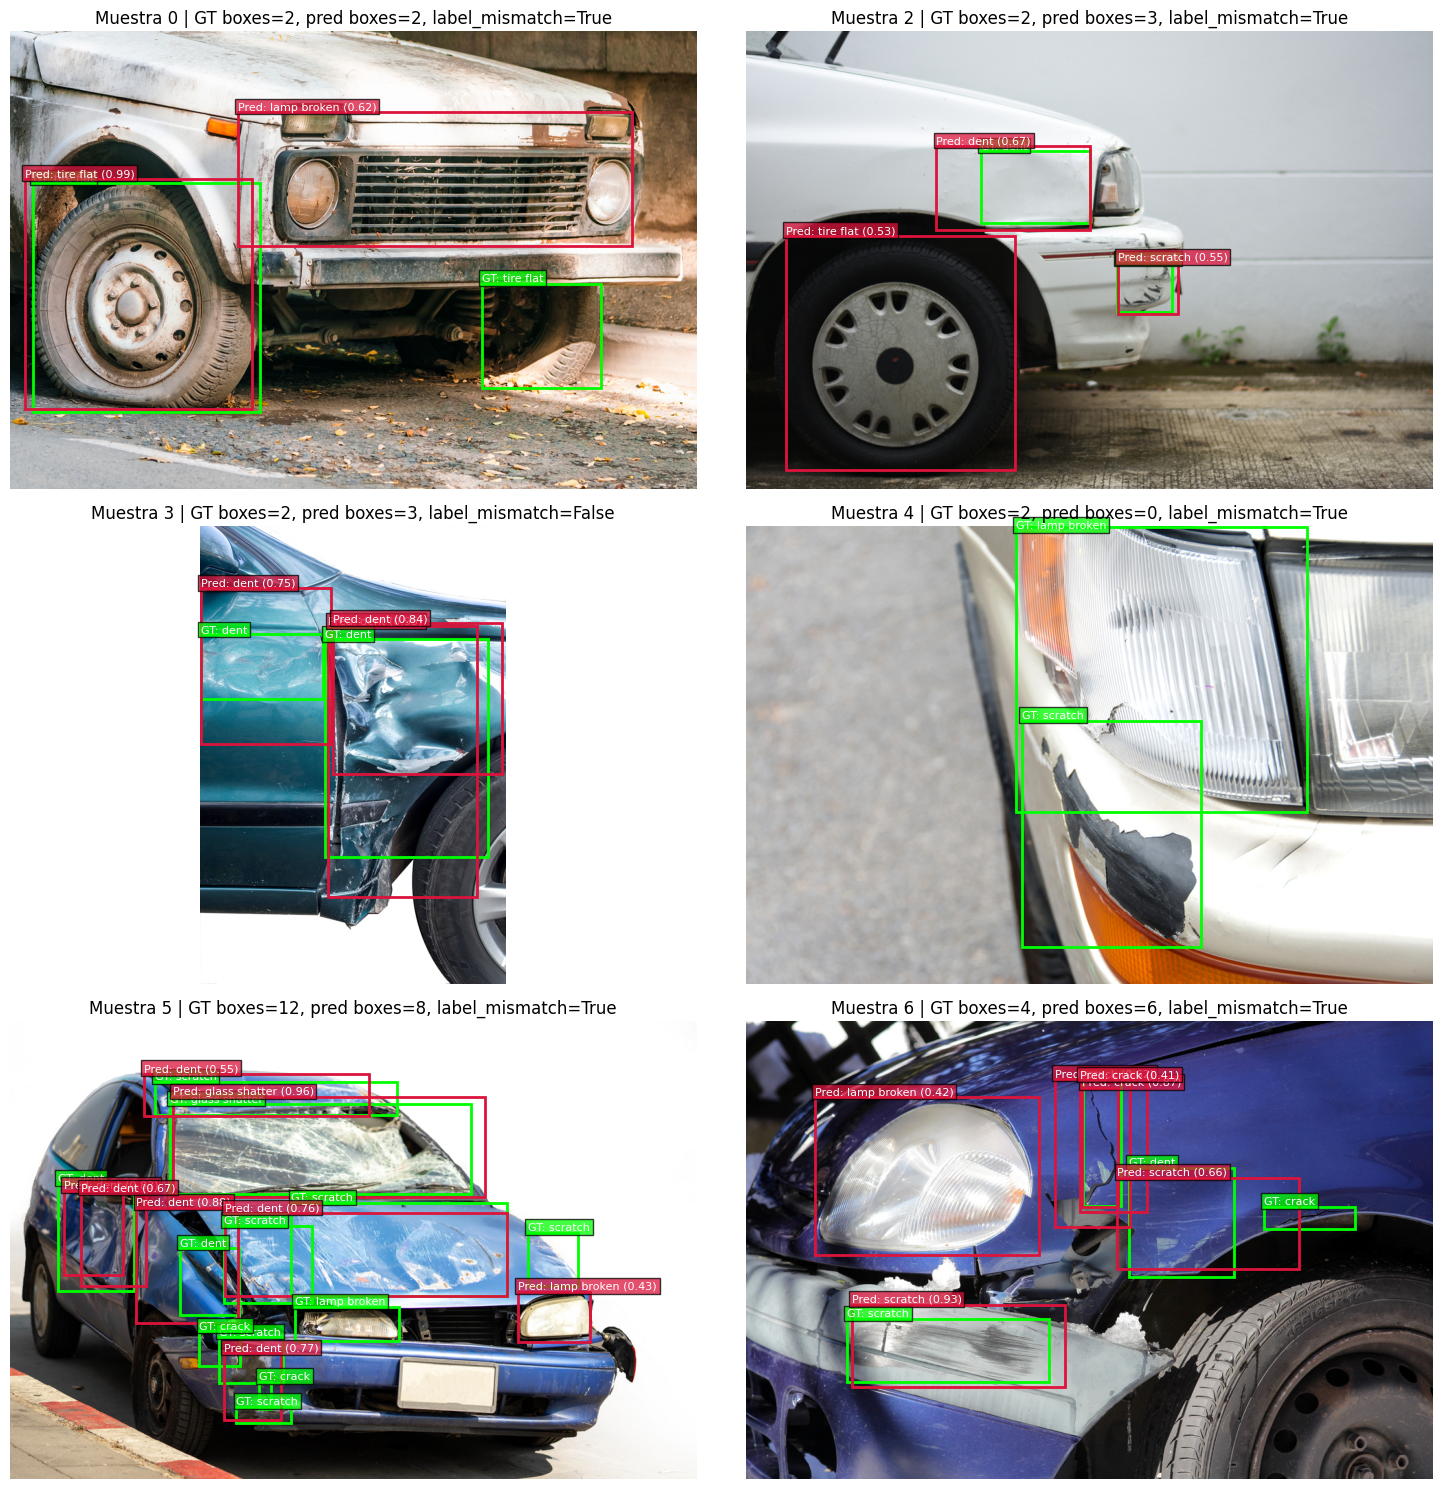

,modelo_final,checkpoint_origen,tamano_modelo_mb,git_lfs_requerido,accion
0,/home/joaquin/code/proyecto_final_redes/dev/mo...,dev/experiments/20260612_153757_fasterrcnn_mob...,142.0,True,ya coincidia en tamano con el mejor checkpoint


In [15]:
# Visualiza errores frecuentes y decide si promover el mejor checkpoint a `dev/modelo.pth`.
# Busca ejemplos del conjunto de test donde la prediccion difiere visiblemente del target.
# El helper devuelve hasta `max_examples` casos problematicos segun una heuristica simple.
error_examples = collect_error_analysis_examples(
    model=best_model,
    dataset=test_dataset_best,
    device=DEVICE,
    score_threshold=0.4,
    max_examples=6,
)

# Dibuja en cada imagen las cajas reales (GT) y las predichas para inspeccionar errores frecuentes.
plot_error_analysis_examples(error_examples, test_dataset_best.idx_to_class)

# Registra que decision se toma respecto del archivo final `dev/modelo.pth`.
promotion_action = "sin cambios"

# Si el modelo final todavia no existe, copia el mejor checkpoint encontrado.
if not FINAL_MODEL_PATH.exists():
    shutil.copy2(best_checkpoint_path, FINAL_MODEL_PATH)
    promotion_action = "copiado porque no existia"

# Si existe pero apunta a otro archivo, compara tamanos para decidir si conviene reemplazarlo.
elif FINAL_MODEL_PATH.resolve() != best_checkpoint_path.resolve():
    if FINAL_MODEL_PATH.stat().st_size != best_checkpoint_path.stat().st_size:
        shutil.copy2(best_checkpoint_path, FINAL_MODEL_PATH)
        promotion_action = "reemplazado por el mejor checkpoint"
    else:
        promotion_action = "ya coincidia en tamano con el mejor checkpoint"

# Si ambos paths coinciden, entonces el mejor checkpoint ya es el modelo final actual.
else:
    promotion_action = "el mejor checkpoint ya era dev/modelo.pth"

# Resume en una tabla la ubicacion del modelo final, su origen, su tamano y si requiere Git LFS.
final_model_df = pd.DataFrame(
    [
        {
            "modelo_final": str(FINAL_MODEL_PATH),
            "checkpoint_origen": to_portable_path(best_checkpoint_path, base_dir=PROJECT_ROOT),
            "tamano_modelo_mb": round(FINAL_MODEL_PATH.stat().st_size / (1024 * 1024), 1),
            "git_lfs_requerido": FINAL_MODEL_PATH.stat().st_size > 100 * 1024 * 1024,
            "accion": promotion_action,
        }
    ]
)
display(final_model_df)



## 14. Resumen final

Mejor mAP:
Faster R-CNN MobileNetV3 Large FPN, SGD, 10 épocas → 0.4411

Mejor relación rendimiento/tiempo:
Faster R-CNN MobileNetV3 Large FPN, SGD, 5 épocas → 0.4375 en 14.7

Modelo one-stage más competitivo:
FCOS, SGD, 5 épocas → 0.4386

RetinaNet:
Quedó por debajo → 0.3705

Faster R-CNN 320:
Más rápido, pero menos preciso

AdamW:
Falló probablemente por LR demasiado alto

# Ver NMS. Bajar umbral de IoU - Como lo hace Pytorch
# Gráfica por Precision - Recall por cada clase
# Tiempo de cada epoch
# Ver por qué son falsos positivos
# Métricas más descriptivas
# Hacer filtrado más agresivo. 
